# 11 — Production ANN Thinking: Monitoring, Drift, Failure Modes, and Business Decisions

The final lesson is that **training accuracy is not the product**. A production ANN is a monitored decision component.

A mature system observes at least four layers:

1. **data quality** — shapes, missingness, range, schema, distribution
2. **model behavior** — confidence, class frequencies, latency, error rate
3. **ground-truth performance** — precision/recall/accuracy once labels arrive
4. **business outcomes** — cost, conversion, review load, risk, SLA, customer impact


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    ids = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        ids.extend(rng.choice(candidates, size=per_class, replace=False))
    ids = np.array(ids)
    rng.shuffle(ids)
    return x[ids], y[ids]

x_train, y_train = balanced_subset(x_train_raw, y_train_raw, 500)
x_test, y_test = balanced_subset(x_test_raw, y_test_raw, 100)
X_train = x_train.reshape(len(x_train), -1).astype('float32') / 255.0
X_test = x_test.reshape(len(x_test), -1).astype('float32') / 255.0
print('teaching train:', X_train.shape, y_train.shape)
print('teaching test :', X_test.shape, y_test.shape)
print('pixel range   :', float(X_train.min()), 'to', float(X_train.max()))


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)
teaching train: (5000, 784) (5000,)
teaching test : (1000, 784) (1000,)
pixel range   : 0.0 to 1.0


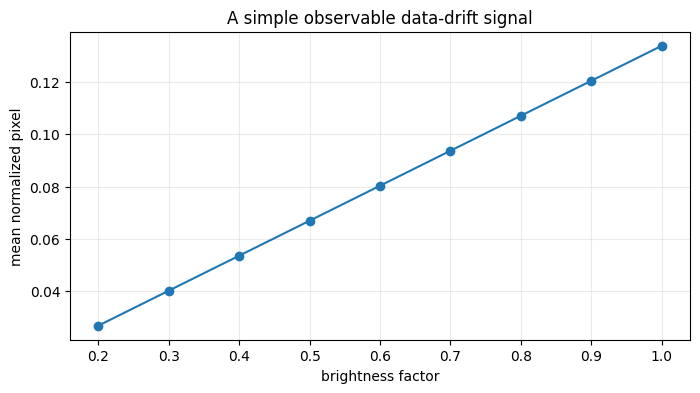

In [2]:
# Simulate a simple input drift: progressively darken images.
factors=np.linspace(1.0,0.2,9)
mean_pixel=[]
for f in factors:
    shifted=np.clip(X_test*f,0,1)
    mean_pixel.append(shifted.mean())
plt.figure(figsize=(8,4)); plt.plot(factors,mean_pixel,marker='o'); plt.xlabel('brightness factor'); plt.ylabel('mean normalized pixel'); plt.title('A simple observable data-drift signal'); plt.grid(alpha=.25); plt.show()


## What would you monitor in a real ANN service?

| Layer | Example signal | Why it matters |
|---|---|---|
| Input | feature distribution / image intensity | detects upstream change |
| Runtime | p50/p95 latency, memory | protects SLA |
| Prediction | confidence distribution | detects behavior shift |
| Class mix | predicted-label frequency | catches population change |
| Outcome | confusion matrix by segment | detects quality regression |
| Business | manual-review volume or cost | confirms economic value |

## Expert checkpoint

After completing this branch you should be able to trace one prediction all the way from pixels to logits, explain how the loss creates gradients, explain how the optimizer changes parameters, visualize how representations change, train a model with an explicit loop, diagnose errors, serialize/reload the artifact, and describe what must be monitored after deployment.

That is the difference between knowing an ANN formula and being able to engineer and reason about an ANN system.


In [3]:
print('Curriculum complete.')
print('You now have the full conceptual chain: data -> forward -> loss -> gradients -> update -> representation -> evaluation -> inference -> monitoring.')


Curriculum complete.
You now have the full conceptual chain: data -> forward -> loss -> gradients -> update -> representation -> evaluation -> inference -> monitoring.
